## **Loading Data, injecting noise, evaluating model**
- 2 Types of Noise: Unit test, Noise Scenarios 
    + Unit Test: Gaussian Noise, Poisson Noise, Salt-and-pepper Noise, Motion Blur, Intensity inhomogeneity, low-contrast degradation,... 

    + Scenarios: Shaking camera, Snow, frost, fog, constrast  

In [2]:
import os
import sys 
import re 
import glob 
import cv2 
os.chdir(r'C:\Users\ADMIN\Documents\SAM\Research')

import torch 
import albumentations as A
import numpy as np 
import matplotlib.pyplot as plt 

from torch.utils.data import DataLoader, Dataset 
from utils.dataLoader import COCOLoader, VOCPascalLoader 
from utils.modelLoader import SAM1


c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Noise Module**


### **Unit Test** 
- Gaussian Noise
- Poisson Noise 
- Salt-and-peper Noise 

In [18]:
# Gaussian Noise 
def _inject_gaussian_noise(image, level:int=1):
    """
    Inject Gaussian Noise into image with certain severity level.

    Args: 
        image (np.array): Input image that need to be noise injected.
        level (int): Severity level (1 - 3).

    Returns: 
        np.array: Gaussian Noise injected Image.
    """
    temp_image = image
    Gaussian_transform = None
    if level == 1: 
        Gaussian_transform = A.GaussNoise(std_range=(0.00, 0.04), p=1) 
    elif level == 2:     
        Gaussian_transform = A.GaussNoise(std_range=(0.04, 0.12), p=1)
    elif level == 3:     
        Gaussian_transform = A.GaussNoise(std_range=(0.12, 0.25), p=1) 

    transformed_image = Gaussian_transform(image=temp_image)['image']
    return transformed_image
    

# Poisson Noise 
def _inject_poisson_noise(image, level:int=1): 
    """
    Inject Poisson Noise into image with certain severity level.

    Args: 
        image (np.array): Input image that need to be noise injected.
        level (int): Severity level (1 - 3).

    Returns: 
        np.array: Poisson Noise injected Image.
    """
    temp_image = image 
    Poisson_transform = None 
    if level == 1: 
        Poisson_transform = A.ShotNoise(scale_range=(0.01, 0.02), p=1) 
    elif level == 2: 
        Poisson_transform = A.ShotNoise(scale_range=(0.05, 0.1), p = 1)
    elif level == 3 : 
        Poisson_transform = A.ShotNoise(scale_range=(0.15, 0.25), p = 1)

    transformed_image = Poisson_transform(image=temp_image)['image']
    return transformed_image
     

# Salt-and-Pepper Noise 
def _inject_salt_and_pepper_noise(image, level:int=1): 
    """
    Inject Salt-and-Pepper Noise into image with certain severity level.

    Args: 
        image (np.array): Input image that need to be noise injected.
        level (int): Severity level (1 - 3).

    Returns: 
        np.array: Salt-and-Pepper Noise injected Image.
    """
    # Implementation for Salt-and-Pepper noise to be added
    temp_image = image 
    salt_and_pepper_transform = None 
    if level == 1: 
        salt_and_pepper_transform = A.SaltAndPepper(amount=(0.01, 0.03), p=1)
    elif level == 2: 
        salt_and_pepper_transform = A.SaltAndPepper(amount=(0.05, 0.15), p=1)
    elif level == 3: 
        salt_and_pepper_transform = A.SaltAndPepper(amount=(0.2, 0.5), p=1)
    
    transformed_image = salt_and_pepper_transform(image=temp_image)['image']
    return transformed_image
    

In [4]:
coco_datapath = r'C:\\Users\\ADMIN\\fiftyone\\coco-2017\\validation\\data'
coco_labelpath = r'C:\Users\ADMIN\fiftyone\coco-2017\raw\instances_val2017.json'
coco_dataset = COCOLoader(coco_datapath=coco_datapath, coco_labelpath=coco_labelpath)


 100% |███████████████| 5000/5000 [1.9m elapsed, 0s remaining, 49.0 samples/s]      


2026-03-23 15:06:39,965 - INFO -  100% |███████████████| 5000/5000 [1.9m elapsed, 0s remaining, 49.0 samples/s]      


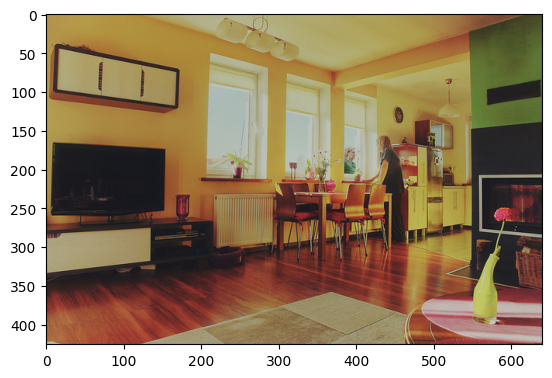

In [5]:
first = coco_dataset[0]
image = first['image'] 
plt.imshow(image)

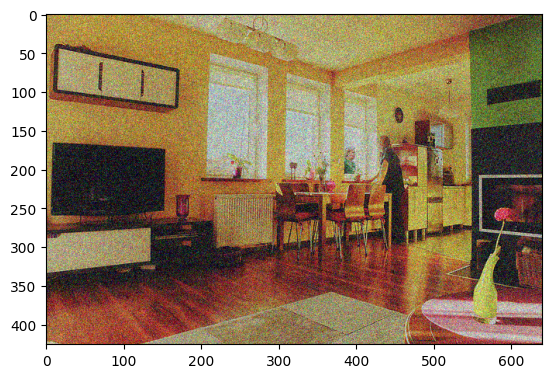

In [6]:
gaussian_image = _inject_gaussian_noise(image=image, level=2)
plt.imshow(gaussian_image)

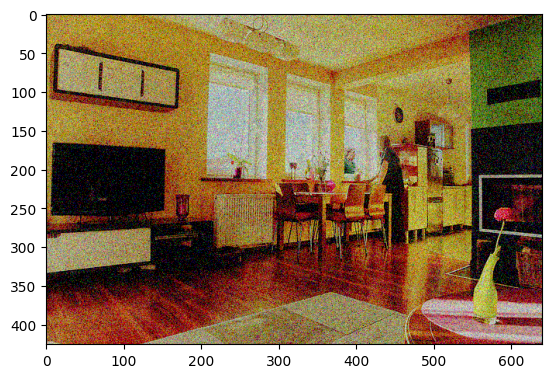

In [7]:
poisson_image = _inject_poisson_noise(image=image, level=2)
plt.imshow(poisson_image)

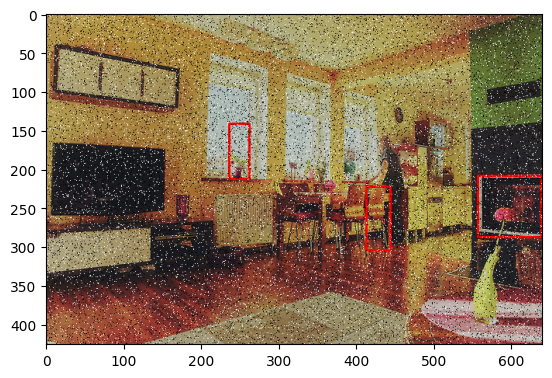

In [19]:
salt_pepper_image = _inject_salt_and_pepper_noise(image=image, level=2)
plt.imshow(salt_pepper_image)

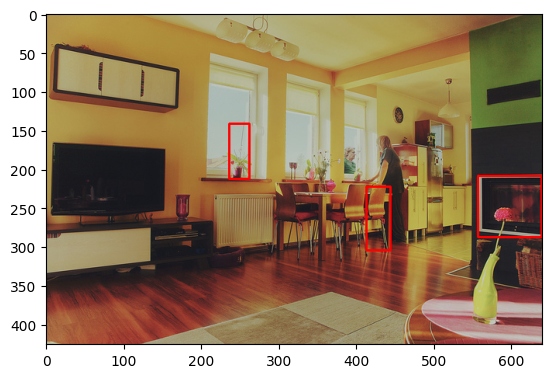

In [16]:
x_min, y_min, x_max, y_max = first['bounding_boxes'][5]
cv2.rectangle(image, (x_min, y_min), (x_max, y_max), color=(255, 0, 0), thickness=2)
plt.imshow(image)
